In [16]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv('housepricedata.csv')
df.head()

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,AboveMedianPrice
0,8450,7,5,856,2,1,3,8,0,548,1
1,9600,6,8,1262,2,0,3,6,1,460,1
2,11250,7,5,920,2,1,3,6,1,608,1
3,9550,7,5,756,1,0,3,7,1,642,0
4,14260,8,5,1145,2,1,4,9,1,836,1


In [10]:
dataset = df.values
X = dataset[:, 0:10]
Y = dataset[:, 10]

min_max_scaler = MinMaxScaler()
X_scaled = min_max_scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size = 0.3, random_state = 42)
X_validation, X_test, Y_validation, Y_test = train_test_split(X_test, Y_test, test_size = 0.5, random_state = 42)

model = Sequential([
    Dense(64, input_shape = (10, ), activation='relu'),
    Dense(32, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

hist = model.fit(X_train, Y_train, validation_data = (X_validation, Y_validation), epochs = 100, batch_size = 32)

I0000 00:00:1789086180.906140  594811 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4130 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/100


I0000 00:00:1789086182.269611  598086 service.cc:153] XLA service 0x766a400432f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789086182.269630  598086 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1789086182.294929  598086 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789086182.439397  598086 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1789086182.447671  598086 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1344__.9


 1/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.4688 - loss: 0.7726

I0000 00:00:1789086183.454727  598086 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1789086183.619582  598086 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1344__.9


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.6067 - loss: 0.6767 - val_accuracy: 0.7854 - val_loss: 0.6092
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8072 - loss: 0.5737 - val_accuracy: 0.8265 - val_loss: 0.5102
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8376 - loss: 0.4872 - val_accuracy: 0.8721 - val_loss: 0.4252
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8493 - loss: 0.4232 - val_accuracy: 0.8858 - val_loss: 0.3669
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8532 - loss: 0.3851 - val_accuracy: 0.8950 - val_loss: 0.3342
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8571 - loss: 0.3630 - val_accuracy: 0.8767 - val_loss: 0.3181
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8552 - loss: 0.3454 - val_accuracy: 0.8767 - val_loss: 0.3025
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8659 - loss: 0.3334 - val_accuracy: 0.8767 - val_loss: 0.

In [11]:
model.evaluate(X_test, Y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9041 - loss: 0.2299 


[0.22994442284107208, 0.9041095972061157]

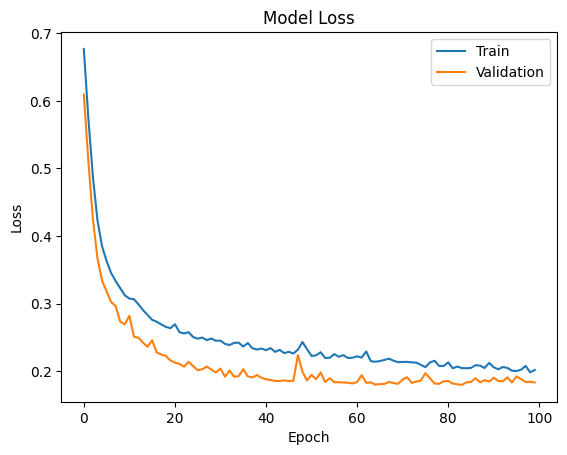

In [13]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper right')
plt.show()

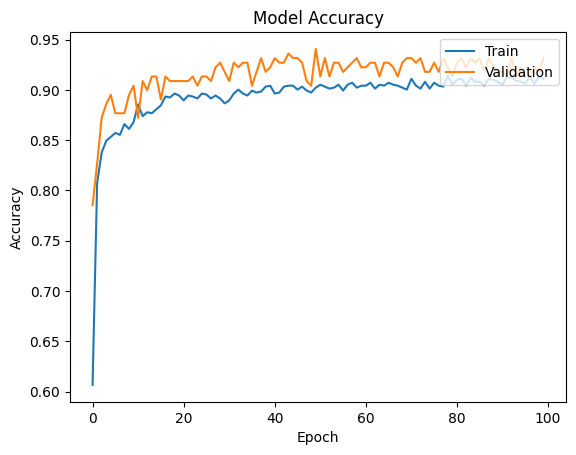

In [14]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper right')
plt.show()

Epoch 1/100


I0000 00:00:1789086473.458848  598086 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21663__.11


 1/32 ━━━━━━━━━━━━━━━━━━━━ 1:18 3s/step - accuracy: 0.6250 - loss: 0.6928

I0000 00:00:1789086475.332454  598089 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21663__.11


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.7759 - loss: 0.4948 - val_accuracy: 0.8584 - val_loss: 0.3430
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8395 - loss: 0.3745 - val_accuracy: 0.8767 - val_loss: 0.3251
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8542 - loss: 0.3493 - val_accuracy: 0.8858 - val_loss: 0.2507
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8826 - loss: 0.3149 - val_accuracy: 0.9041 - val_loss: 0.2434
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8718 - loss: 0.2904 - val_accuracy: 0.9041 - val_loss: 0.2271
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8728 - loss: 0.3031 - val_accuracy: 0.9041 - val_loss: 0.2412
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8826 - loss: 0.3017 - val_accuracy: 0.9224 - val_loss: 0.1979
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8845 - loss: 0.2895 - val_accuracy: 0.9132 - val_loss: 0

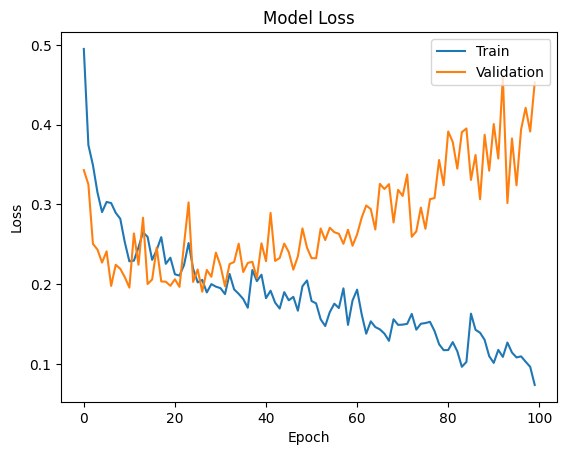

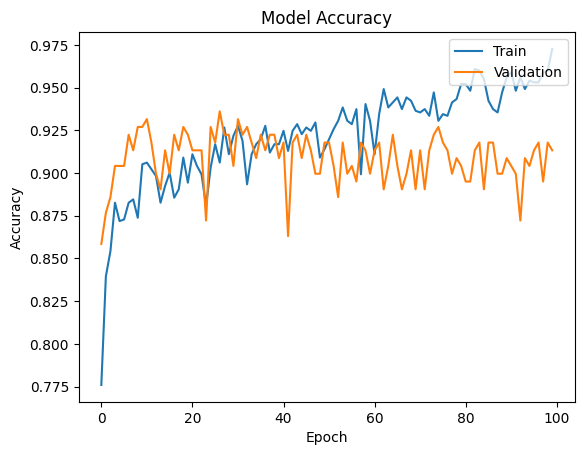

In [15]:
model_2 = Sequential([
    Dense(1000, input_shape = (10, ), activation='relu'),
    Dense(1000, activation = 'relu'),
    Dense(1000, activation = 'relu'),
    Dense(1000, activation = 'relu'),
    Dense(1, activation = 'sigmoid')])

model_2.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
hist_2 = model_2.fit(X_train, Y_train, validation_data = (X_validation, Y_validation), epochs = 100, batch_size = 32)

plt.plot(hist_2.history['loss'])
plt.plot(hist_2.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper right')
plt.show()


plt.plot(hist_2.history['accuracy'])
plt.plot(hist_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper right')
plt.show()

Epoch 1/100


I0000 00:00:1789086688.062294  598088 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_42278__.15


24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5522 - loss: 0.6635 

I0000 00:00:1789086690.258880  598088 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_42278__.15


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.6693 - loss: 0.5945 - val_accuracy: 0.8402 - val_loss: 0.3809
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8307 - loss: 0.4130 - val_accuracy: 0.8584 - val_loss: 0.3208
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8425 - loss: 0.3684 - val_accuracy: 0.8950 - val_loss: 0.2730
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8669 - loss: 0.3359 - val_accuracy: 0.8950 - val_loss: 0.2502
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8454 - loss: 0.3636 - val_accuracy: 0.8676 - val_loss: 0.2956
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8571 - loss: 0.3403 - val_accuracy: 0.8904 - val_loss: 0.2496
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8669 - loss: 0.3151 - val_accuracy: 0.8995 - val_loss: 0.2250
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8718 - loss: 0.3010 - val_accuracy: 0.9041 - val_loss: 0.

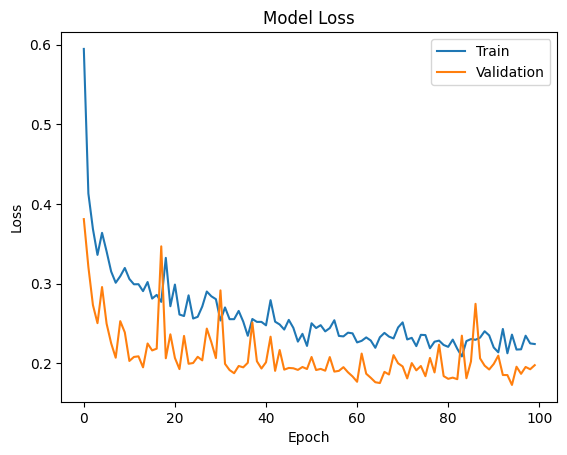

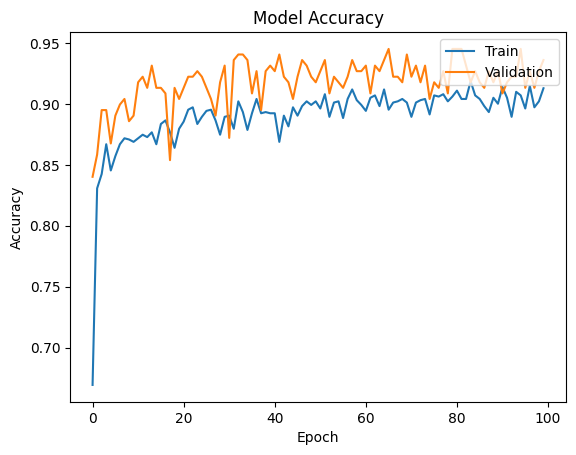

In [17]:
model_3 = Sequential([
    Dense(1000, input_shape = (10, ), activation='relu'),
    Dropout(0.5),
    Dense(1000, activation = 'relu'),
    Dropout(0.5),
    Dense(1000, activation = 'relu'),
    Dropout (0.5),
    Dense(1000, activation = 'relu'),
    Dropout(0.5),
    Dense(1, activation = 'sigmoid')])

model_3.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
hist_3 = model_3.fit(X_train, Y_train, validation_data = (X_validation, Y_validation), epochs = 100, batch_size = 32)

plt.plot(hist_3.history['loss'])
plt.plot(hist_3.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper right')
plt.show()


plt.plot(hist_3.history['accuracy'])
plt.plot(hist_3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper right')
plt.show()